# MTG Image Recognition

Projekat iz **Mašinskog učenja**.
Cilj: naučiti model da prepozna kartu slikanu kamerom, na osnovu treninga nad slikama velike rezolucije koje su prethodno pripremljene augmentacijom podataka.

In [1]:
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from src.augment import augment_image, augment_image_x_times
from src.helper import (
    encode_images,
    load_images_from_folder,
    save_encoded_images,
    save_pil_images,
)
from src.build_dataset import CARD_LABELS, build_dataset

random.seed(42)

## Podaci

Bazne slike („raw", originalni skenovi) su u `data/raw/<naziv karte>/`.
Svaka klasa ima jednu visoko-rezolutivnu sliku karte.

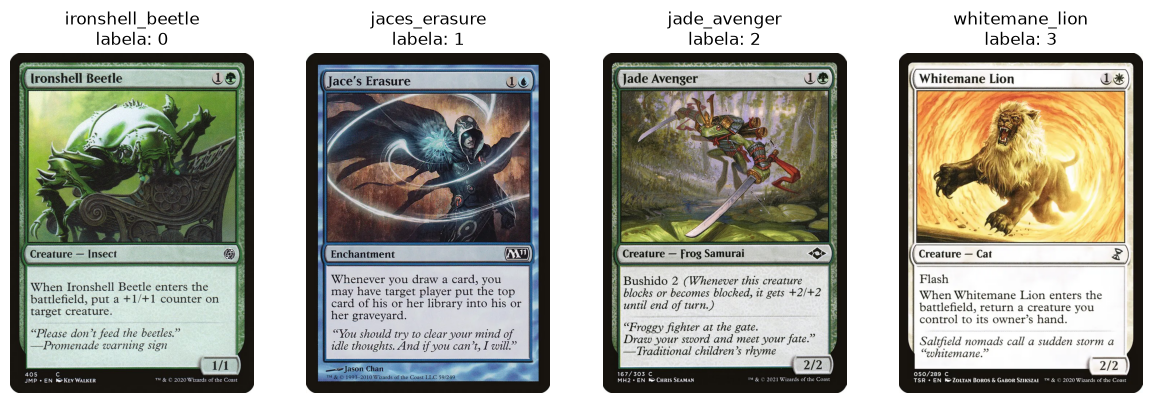

In [2]:
fig, axes = plt.subplots(1, len(CARD_LABELS), figsize=(3 * len(CARD_LABELS), 4))

for ax, (card, label) in zip(axes.flat, CARD_LABELS.items()):
    raw_images = load_images_from_folder(f"data/raw/{card}")
    ax.imshow(raw_images[0])
    ax.set_title(f"{card}\nlabela: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Augmentacija

Augmentacija simulira razlike u kadriranju, položaju i osvetljenju koje nastanu kada se karta slika telefonom.
`src/augment.py` primenjuje nasumično:

- horizontalni flip (50% šanse)
- rotaciju +- 15 stepeni
- promenu osvetljenja (0.8–1.2×)
- promenu kontrasta (0.8–1.2×)

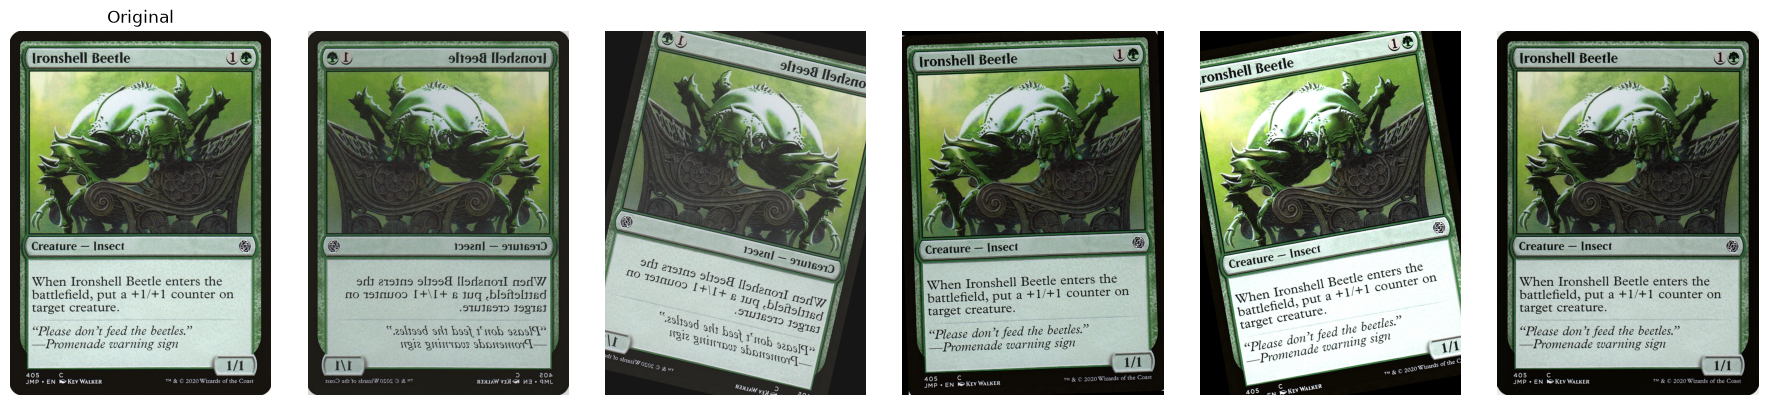

In [3]:
img = load_images_from_folder("data/raw/ironshell_beetle")[0]
augmented = augment_image_x_times(img, 5)

fig, axes = plt.subplots(1, 6, figsize=(3 * 6, 4))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, aug in zip(axes[1:], augmented):
    ax.imshow(aug)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Pipeline podataka

`src/build_dataset.py`

Za svaku kartu:
1. učitava raw slike (`load_images_from_folder`)
2. pravi **10 augmentovanih kopija** po slici (`augment_image_x_times`)
3. čuva kopije u punoj rezoluciji u `data/augmented/<karta>/`
4. enkoduje (resize na 32×32, normalizacija, spljošteno u 1D niz) i čuva u `data/encoded/<karta>/`
5. na kraju čuva `data/encoded/X.npy` i `data/encoded/y.npy`

In [4]:
X, y = build_dataset()

print(f"X shape: {X.shape}   (broj primera, 32*32*3)")  # 40 = 4 klase x 10 augmentacija
print(f"y shape: {y.shape}   (labela 0-3 za svaku sliku)")
print(f"Raspodela po klasama:")
for card, label in CARD_LABELS.items():
    print(f"  {label}: {card}, {np.sum(y == label)} primera")

X shape: (40, 3072)   (broj primera, 32*32*3)
y shape: (40,)   (labela 0-3 za svaku sliku)
Raspodela po klasama:
  0: ironshell_beetle, 10 primera
  1: jaces_erasure, 10 primera
  2: jade_avenger, 10 primera
  3: whitemane_lion, 10 primera


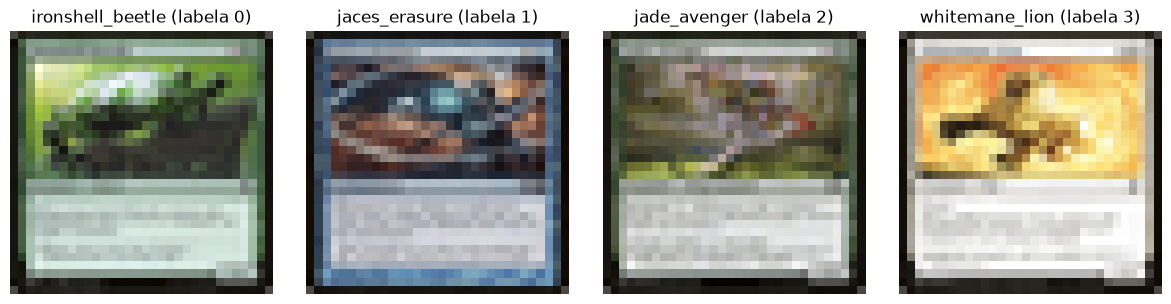

In [5]:
# Pregled enkodovanih slika (32x32) iz foldera raw
fig, axes = plt.subplots(1, len(CARD_LABELS), figsize=(3 * len(CARD_LABELS), 3))

for ax, (card, label) in zip(axes.flat, CARD_LABELS.items()):
    raw = load_images_from_folder(f"data/raw/{card}")[0]
    encoded = encode_images([raw])[0].reshape(32, 32, 3)
    ax.imshow(encoded)
    ax.set_title(f"{card} (labela {label})")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Treniranje CNN modela

`src/cnn.py` definiše arhitekturu mreže, a `src/train.py` je skripta za treniranje.

**Arhitektura:**
- `Conv2D(32) + MaxPool(2x2)` - izvlači jednostavne obrasce (ivice, boje, teksture)
- `Conv2D(64) + MaxPool(2x2)` - složenije kombinacije prvih obrazaca
- `Flatten -> Dense(128) -> Dropout(0.3) -> Dense(num_classes, softmax)` - klasifikator

**Kompajliranje:**
- `optimizer="adam"` - adaptivni gradijentni spust
- `loss="sparse_categorical_crossentropy"` - klasifikacija gde je labela ceo broj (0-3)
- `metrics=["accuracy"]`


In [6]:
from src.cnn import build_cnn
from src.train import load_augmented_data, load_raw_test_data

X, y = load_augmented_data()                  # 40 augmentovanih (trening)
X_test, y_test = load_raw_test_data()         # 4 neaugmentovana originala (test)

print("Trening (augmentovani):", X.shape)
print("Test (neaugmentovani):", X_test.shape)
print("Labele testa:", y_test)

I0000 00:00:1789844810.047293   38195 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789844810.047633   38195 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789844810.066923   38195 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789844810.759084   38195 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

Trening (augmentovani): (40, 32, 32, 3)
Test (neaugmentovani): (4, 32, 32, 3)
Labele testa: [0 1 2 3]


In [7]:
model = build_cnn(num_classes=len(CARD_LABELS))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

E0000 00:00:1789844811.418119   38195 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1789844811.418278   38270 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1789844811.441330   38195 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,948 (1.20 MB)

 Trainable params: 314,948 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## Treniranje

In [8]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
X_sh, y_sh = X[idx], y[idx]

history = model.fit(
    X_sh, y_sh,
    epochs=30,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step - accuracy: 0.1250 - loss: 1.4603 - val_accuracy: 0.2500 - val_loss: 1.4427
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3438 - loss: 1.3221 - val_accuracy: 0.2500 - val_loss: 1.4878
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3125 - loss: 1.3389 - val_accuracy: 0.2500 - val_loss: 1.4006
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4375 - loss: 1.2538 - val_accuracy: 0.6250 - val_loss: 1.2768
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5938 - loss: 1.1909 - val_accuracy: 0.6250 - val_loss: 1.1914
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6562 - loss: 1.1945 - val_accuracy: 0.6250 - val_loss: 1.1210
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7500 - loss: 1.0865 - val_accuracy: 0.6250 - val_loss: 1.0793
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7500 - loss: 1.0349 - val_accuracy: 0.7500 - val_loss: 1.0308

In [10]:
from src.predict import load_model, predict_directory

model = load_model()
results, _ = predict_directory(model)

for name, card, conf in results:
    print(f"{name:<8} {card:<20} {conf:.2%}")

1.jpg    whitemane_lion       71.64%
10.jpg   ironshell_beetle     61.89%
11.jpg   jade_avenger         69.96%
12.jpg   jade_avenger         95.54%
13.jpg   jade_avenger         54.91%
14.jpg   jade_avenger         67.99%
15.jpg   jade_avenger         58.74%
17.jpg   whitemane_lion       98.36%
2.jpg    jaces_erasure        45.30%
3.jpg    whitemane_lion       99.93%
4.jpg    whitemane_lion       80.35%
5.jpg    whitemane_lion       98.32%
6.jpg    whitemane_lion       87.84%
7.jpg    jade_avenger         61.65%
8.jpg    jade_avenger         71.70%
9.jpg    whitemane_lion       99.66%


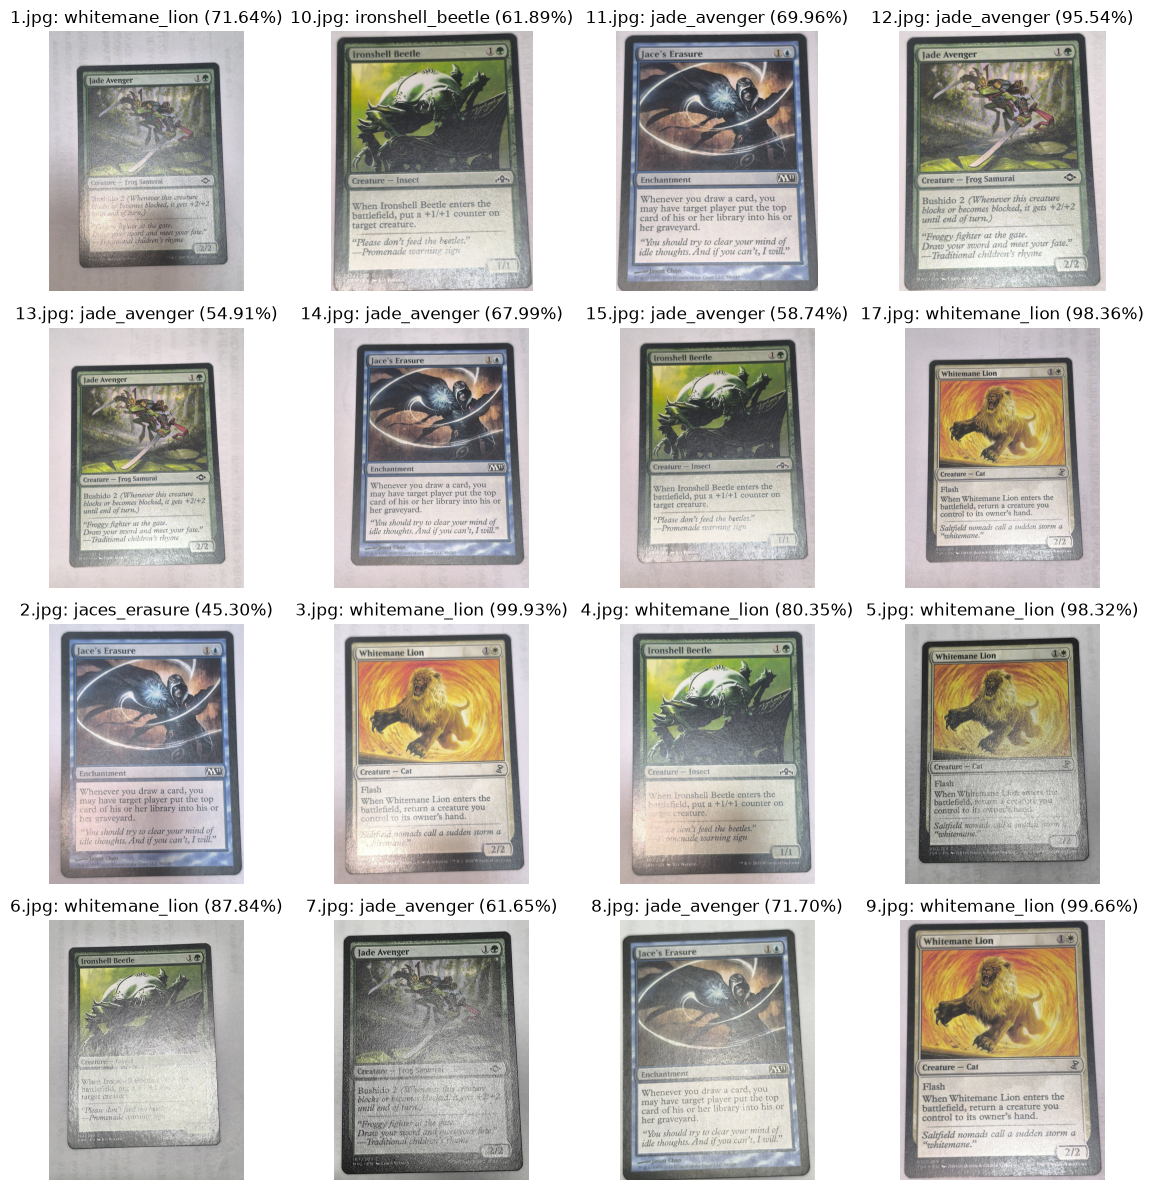

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, (name, card, conf) in zip(axes.flat, results):
    img = Image.open(f"data/test/{name}")
    ax.imshow(img)
    ax.set_title(f"{name}: {card} ({conf:.2%})")
    ax.axis("off")
plt.tight_layout()
plt.show()